# **IPL Player Auction Price Prediction System**

# **Sprint - 1**

**🎯 Problem Statement**

In the Indian Premier League (IPL), franchises invest heavily in players during auctions. However, deciding how much a player is worth is complex and depends on multiple factors like past performance, experience, and skills.
The challenge is:
Can we predict a player's auction price based on their historical performance and attributes?

**🔍 Objective:**

Build a regression model that predicts the auction price of a player using performance metrics and player characteristics.

**💡 Business Impact:**

Helps teams make data-driven bidding decisions
Avoids overpaying or undervaluing players
Identifies undervalued high-potential players
Improves overall team-building strategy


**`  Step 1: Data Collection & Loading:`**

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

In [136]:
df = pd.read_csv("/content/IPL_Auction_Player_Performance_Analytics.csv")

In [137]:
df.shape

(12000, 13)

It consists of:

12,000 rows

13 columns

In [138]:
df.columns

Index(['Name', 'Age', 'Country', 'Role', 'Matches', 'Experience ( in Yrs)',
       'Runs', 'Strike_Rate', 'Wickets', 'Economy', 'Average',
       'Team_Preference', 'Auction_Price ( in Cr )'],
      dtype='object')

In [139]:
df.head()

,Name,Age,Country,Role,Matches,Experience ( in Yrs),Runs,Strike_Rate,Wickets,Economy,Average,Team_Preference,Auction_Price ( in Cr )
0,MS Dhoni,42,India,Wicketkeeper,350,20,12000,135.0,0,0.00,50.00,CSK,20.0
1,Sachin Tendulkar,45,India,Batter,400,24,18000,125.0,5,8.50,45.00,MI,1.5
2,Virat Kohli,36,India,Batter,300,16,13000,138.0,2,7.00,52.00,RCB,18.0
3,Rohit Sharma,37,India,Batter,280,17,14000,132.0,0,8.00,48.00,MI,18.0
4,Jasprit Bumrah,35,India,Bowler,196,7,2661,144.9,798,7.69,27.43,MI,12.0


df.head() gives the top 5 rows of dataset.

In [140]:
df.tail()

,Name,Age,Country,Role,Matches,Experience ( in Yrs),Runs,Strike_Rate,Wickets,Economy,Average,Team_Preference,Auction_Price ( in Cr )
11995,Aravinda de Silva,29,Sri Lanka,Batter,22,1,14111,136.0,11,8.87,35.83,DC,12.0
11996,Inzamam-ul-Haq,26,Pakistan,Batter,72,4,9945,104.1,12,6.87,36.04,PBKS,0.2
11997,Javed Miandad,29,Pakistan,Batter,153,9,12993,106.3,7,9.10,39.90,KKR,12.0
11998,Saqlain Mushtaq,23,Pakistan,Bowler,27,1,1771,133.2,544,7.65,35.40,RR,0.2
11999,Shahid Afridi,38,Pakistan,Allrounder,102,6,4980,144.5,127,7.51,40.67,SRH,10.0


df.tail() gives last 5 rows of dataset.

**`  Step 2: Initial Data Inspection`**

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Name                     12000 non-null  object 
 1   Age                      12000 non-null  int64  
 2   Country                  12000 non-null  object 
 3   Role                     12000 non-null  object 
 4   Matches                  12000 non-null  int64  
 5   Experience ( in Yrs)     12000 non-null  int64  
 6   Runs                     12000 non-null  int64  
 7   Strike_Rate              12000 non-null  float64
 8   Wickets                  12000 non-null  int64  
 9   Economy                  12000 non-null  float64
 10  Average                  12000 non-null  float64
 11  Team_Preference          12000 non-null  object 
 12  Auction_Price ( in Cr )  12000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 1.2+ MB


This tells us:

* Number of rows

* Number of columns

* Column names

* Data types

* Non-null values

In [142]:
df.describe()

,Age,Matches,Experience ( in Yrs),Runs,Strike_Rate,Wickets,Economy,Average,Auction_Price ( in Cr )
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,30.094667,146.447167,6.523083,5897.813833,125.118867,191.803500,5.068873,37.386247,3.729067
std,7.191883,125.774590,5.361237,3630.126361,17.270469,246.319993,3.167495,10.094644,3.693414
min,18.000000,15.000000,1.000000,0.000000,95.000000,0.000000,0.000000,20.000000,0.200000
25%,24.000000,46.000000,2.000000,2986.750000,110.300000,0.000000,0.000000,28.570000,1.000000
50%,30.000000,108.000000,5.000000,5359.500000,125.200000,15.000000,6.220000,37.340000,2.000000
75%,36.000000,217.000000,10.000000,8450.250000,140.100000,351.000000,7.420000,46.092500,5.000000
max,45.000000,713.000000,24.000000,18000.000000,155.000000,900.000000,9.500000,55.000000,20.000000


This helps us understand:

* Mean

* Standard deviation

* Minimum

* Maximum

* Quartiles

In [143]:
#checking null values
df.isnull().sum()

,0
Name,0
Age,0
Country,0
Role,0
Matches,0
Experience ( in Yrs),0
Runs,0
Strike_Rate,0
Wickets,0
Economy,0


-> From this, we have 0 missing values.

-> So we do not need to perform missing-value imputation.

-> Don't artificially fill missing values when there aren't any.

In [144]:
#checking duplicate values
print(df.duplicated().sum())

0


Here, we do not hava any dupliacte values.

Therefore, there is nothing to remove.

In [145]:
df = df.drop_duplicates()

In [146]:
print(df.duplicated().sum())

0


In [147]:
#checking unique values for categorical data
print("Countries:", df["Country"].nunique())
print("Roles:", df["Role"].nunique())
print("Teams:", df["Team_Preference"].nunique())

Countries: 9
Roles: 4
Teams: 11


In [148]:
print(df["Role"].value_counts())

Role
Wicketkeeper    3065
Batter          3002
Allrounder      2967
Bowler          2966
Name: count, dtype: int64


This helps us understand the distribution of player roles.

**`Step 3: Data Cleaning`**

In [149]:
#renaming the columns
df = df.rename(columns={
    "Experience ( in Yrs)": "Experience_Years",
    "Auction_Price ( in Cr )": "Auction_Price"
})

In [150]:
df.columns

Index(['Name', 'Age', 'Country', 'Role', 'Matches', 'Experience_Years', 'Runs',
       'Strike_Rate', 'Wickets', 'Economy', 'Average', 'Team_Preference',
       'Auction_Price'],
      dtype='object')

In [151]:
#verifying data types
df.dtypes

,0
Name,object
Age,int64
Country,object
Role,object
Matches,int64
Experience_Years,int64
Runs,int64
Strike_Rate,float64
Wickets,int64
Economy,float64


Here,

Numerical columns → int64 / float64

Categorical columns → object

We'll check whether numerical columns contain impossible values.

We'll inspect these results before deciding whether any values need treatment.

**`Step 4: Exploratory Data Analysis (EDA)`**

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [153]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()


**1. Univariate Analysis**

Univariate analysis means analyzing one variable at a time.

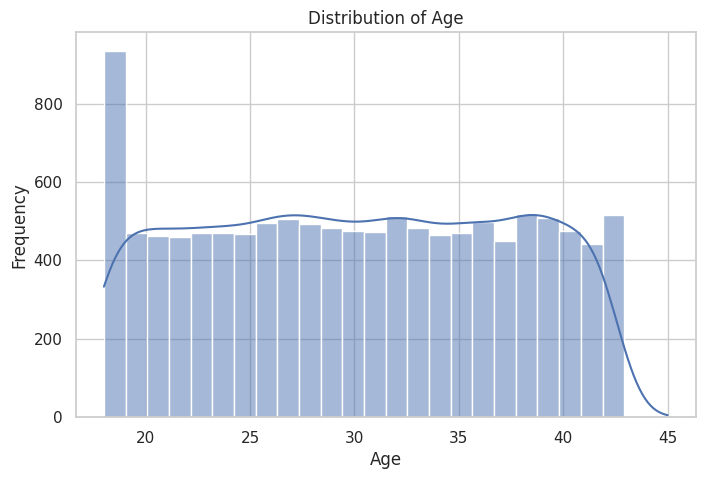

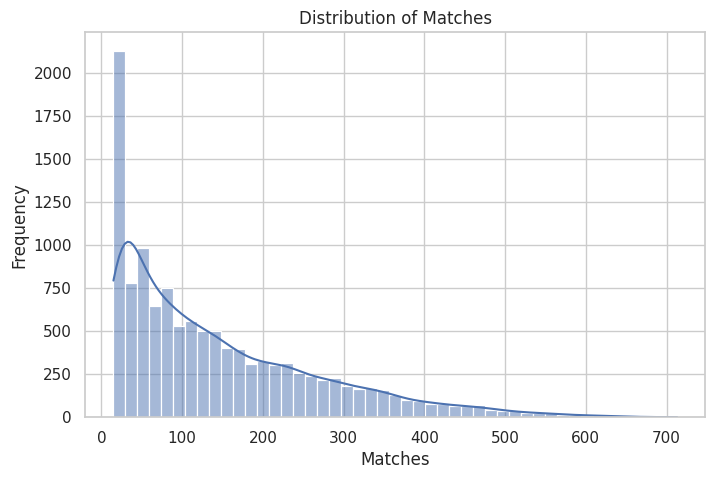

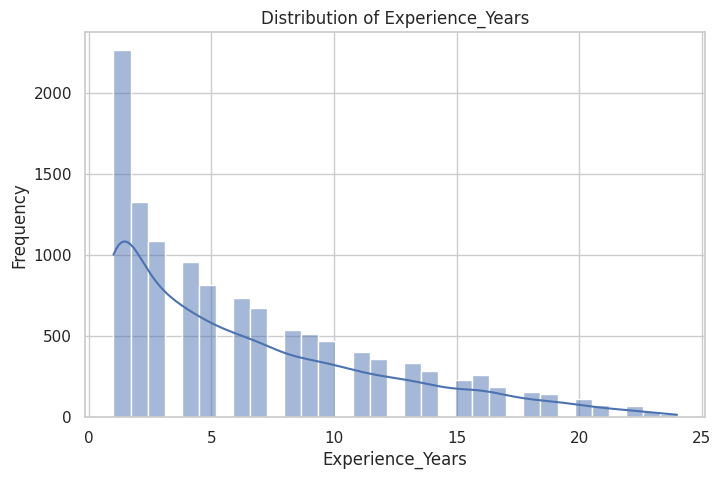

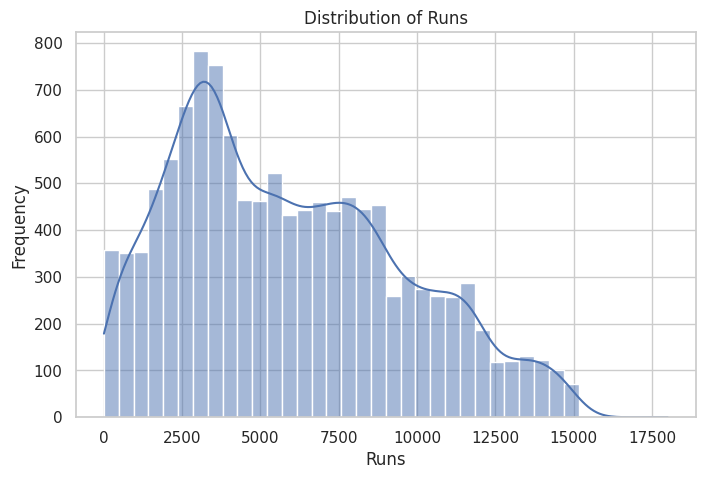

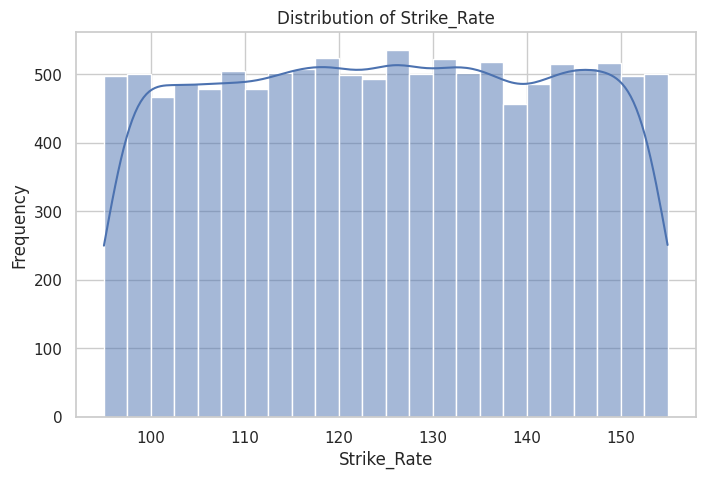

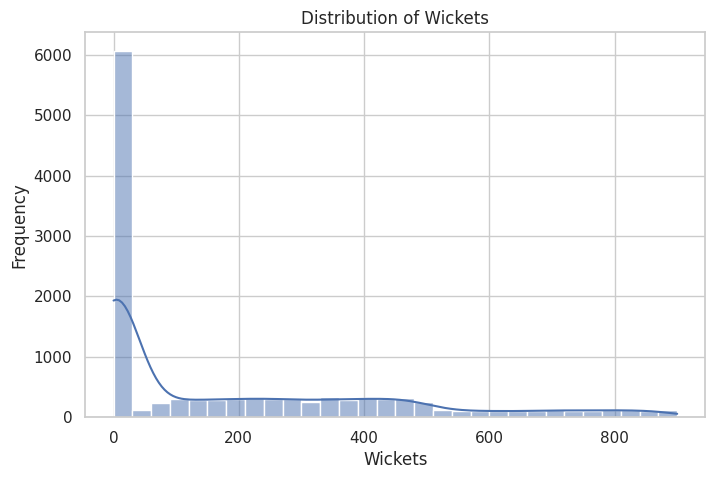

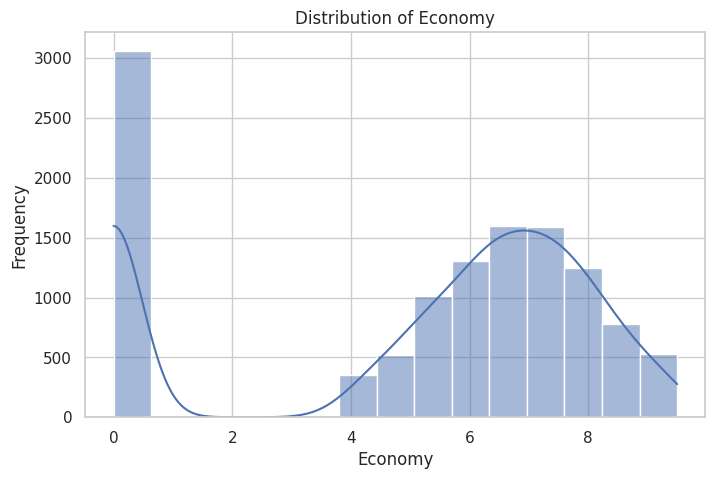

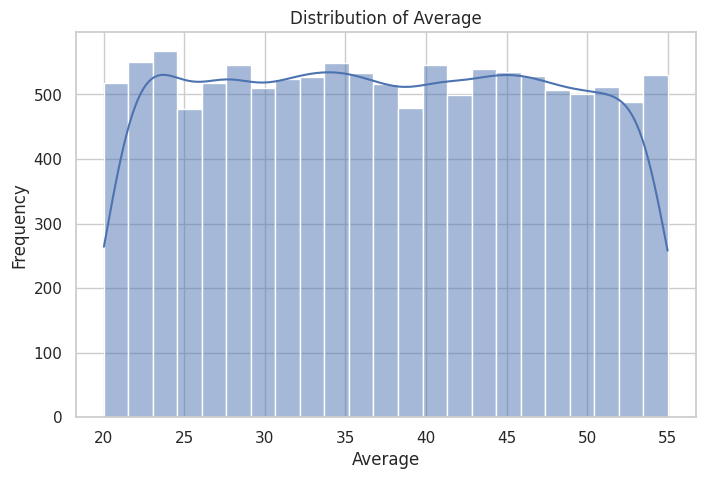

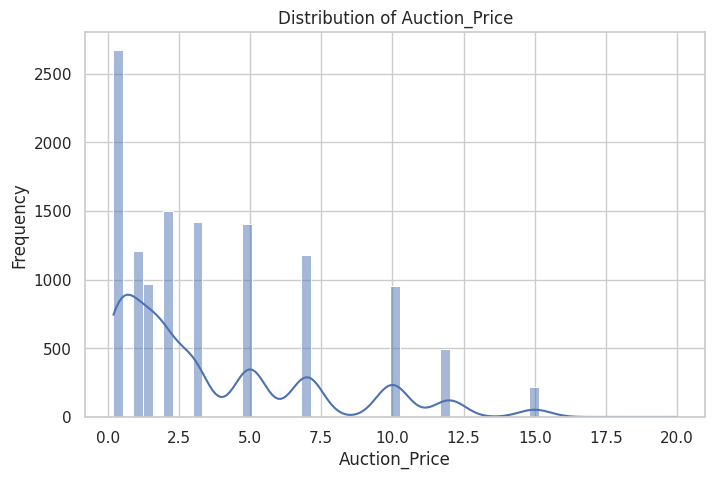

In [154]:
#Distribution of numerical variables

for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

This gives you the distribution of every numerical feature.

In [155]:
#Identify skewness
skewness = df[numerical_cols].skew().sort_values(ascending=False)

print(skewness)

Auction_Price       1.201364
Matches             1.198591
Wickets             1.164379
Experience_Years    0.993893
Runs                0.479362
Average             0.011310
Strike_Rate        -0.008780
Age                -0.013877
Economy            -0.727076
dtype: float64


* Skewness ≈ 0       → Approximately symmetric
* Skewness > 0       → Right-skewed
* Skewness < 0       → Left-skewed

1. The skewness values were calculated for all numerical features to identify non-symmetric distributions and potential transformations.

2. For example, if Auction_Price has high positive skewness, it means most players have relatively lower auction prices while a smaller number of players have very high prices

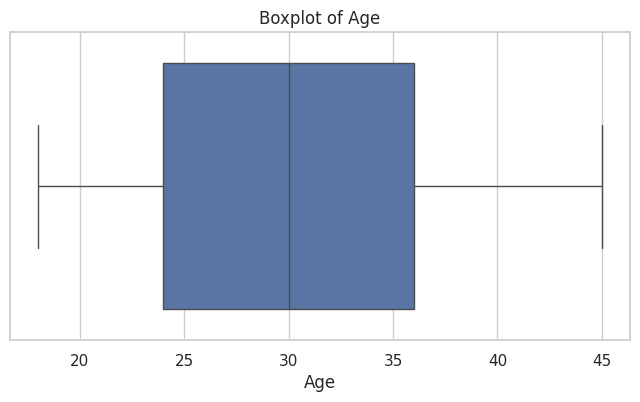

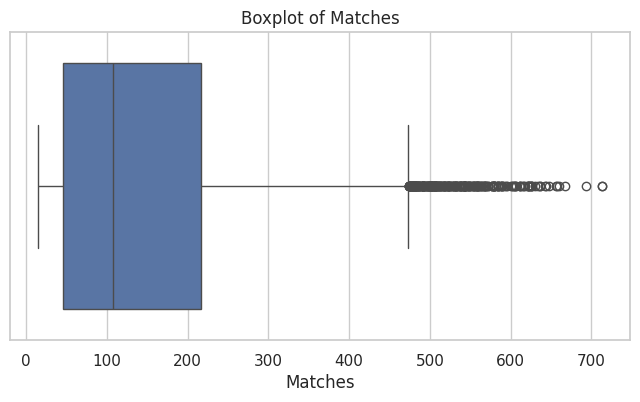

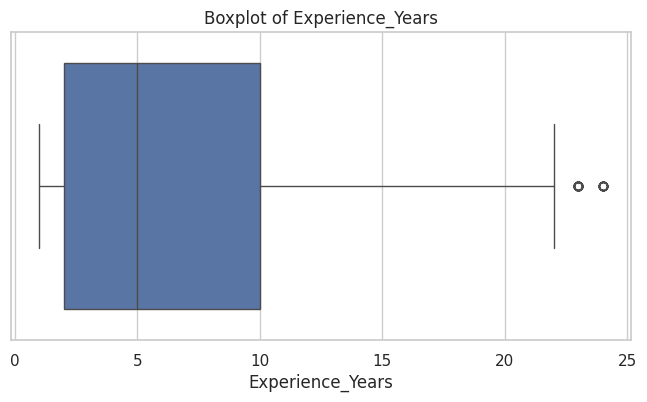

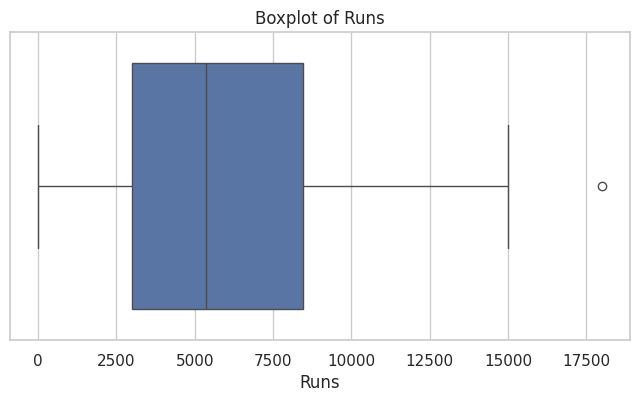

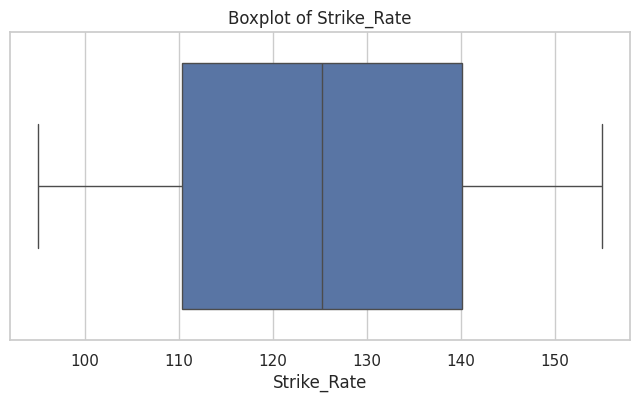

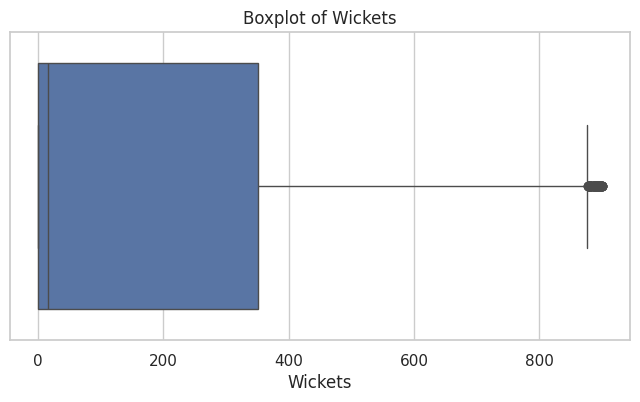

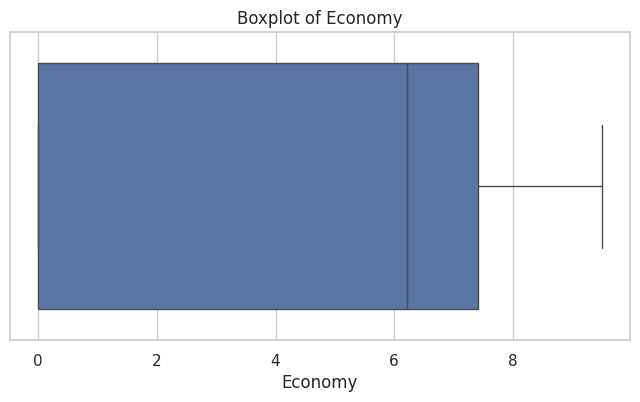

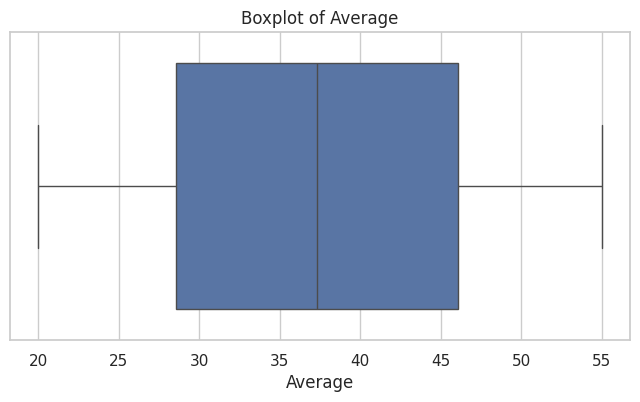

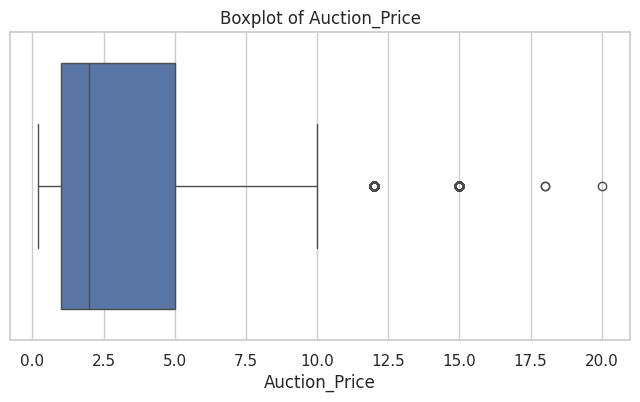

In [156]:
#Boxplots for numerical variables
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

This will also help us identify potential outliers.

* The boxplots provide a visual representation of the median, spread, and potential outliers for each numerical feature. Variables with observations outside the whiskers should be investigated further during the outlier-treatment stage.

**Categorical Univariate Analysis**

In [157]:
categorical_cols = [
    "Country",
    "Role",
    "Team_Preference"
]

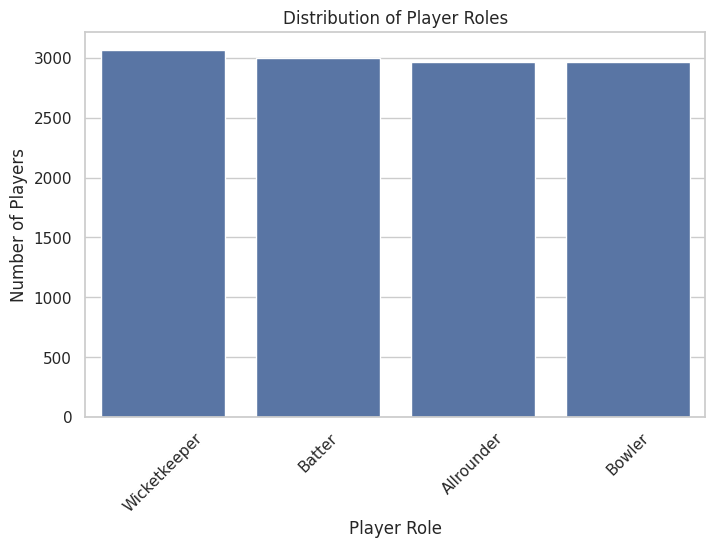

In [158]:
#Player roles
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Role",
    order=df["Role"].value_counts().index
)

plt.title("Distribution of Player Roles")
plt.xlabel("Player Role")
plt.ylabel("Number of Players")
plt.xticks(rotation=45)
plt.show()

* The role distribution shows how players are divided among different playing roles. This helps understand the composition of the dataset and whether some player roles are more represented than others

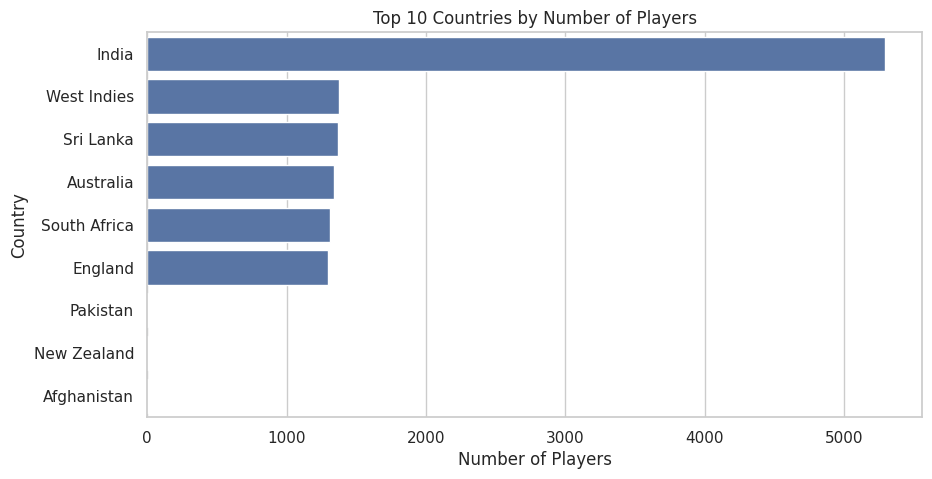

In [159]:
#Country distribution
top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Number of Players")
plt.xlabel("Number of Players")
plt.ylabel("Country")
plt.show()

* The country distribution shows the representation of players from different countries. The top-country analysis helps identify which countries contribute the largest number of players to the dataset.

Because there may be many countries, showing every category may become crowded.



**Bivariate Analysis**

Bivariate analysis means studying the relationship between two variables.

The most important relationship is:

Feature → Auction_Price

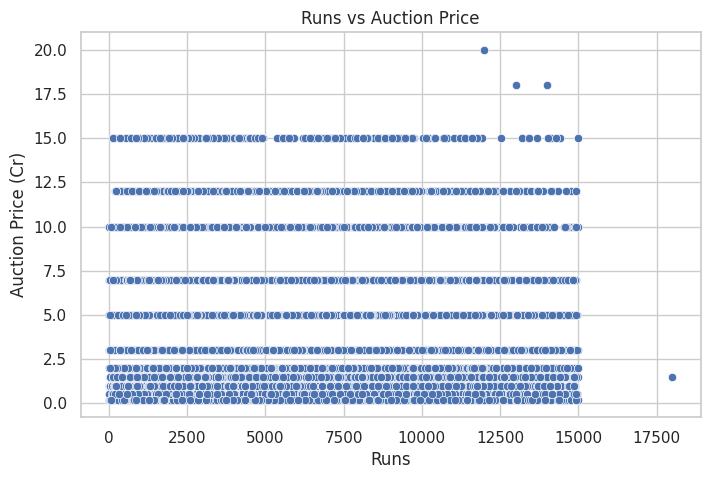

In [160]:
#Runs vs Auction Price
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Runs",
    y="Auction_Price"
)

plt.title("Runs vs Auction Price")
plt.xlabel("Runs")
plt.ylabel("Auction Price (Cr)")
plt.show()

This helps us understand whether players with more runs tend to have higher auction prices.

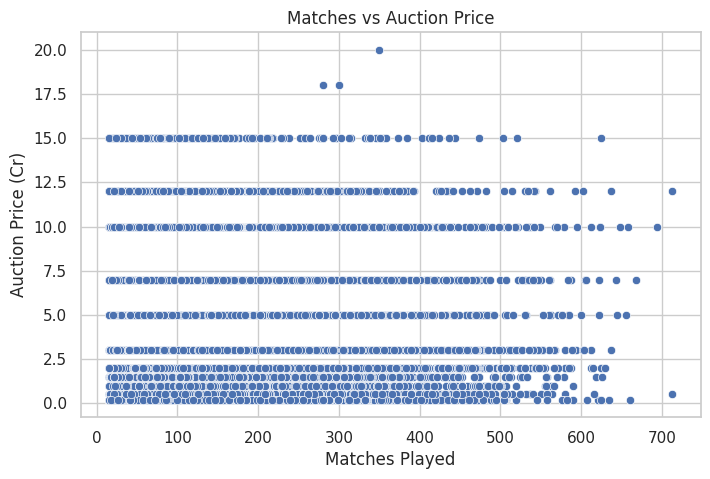

In [161]:
#Matches vs Auction Price
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Matches",
    y="Auction_Price"
)

plt.title("Matches vs Auction Price")
plt.xlabel("Matches Played")
plt.ylabel("Auction Price (Cr)")
plt.show()

* The relationship between matches played and auction price helps determine whether players with greater match experience tend to receive different auction valuations. The scatter pattern also shows the strength and variability of this relationship.

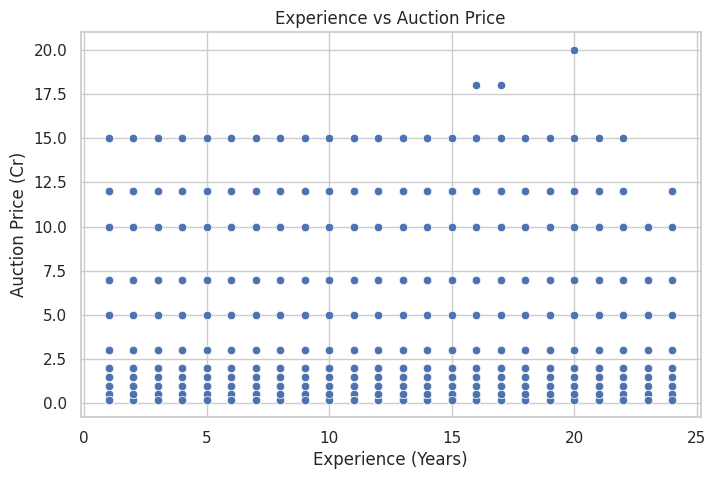

In [162]:
#Experience vs Auction Price
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Experience_Years",
    y="Auction_Price"
)

plt.title("Experience vs Auction Price")
plt.xlabel("Experience (Years)")
plt.ylabel("Auction Price (Cr)")
plt.show()

* The plot examines whether professional experience is associated with auction price. It helps determine whether experienced players generally show different valuation patterns compared with less-experienced players

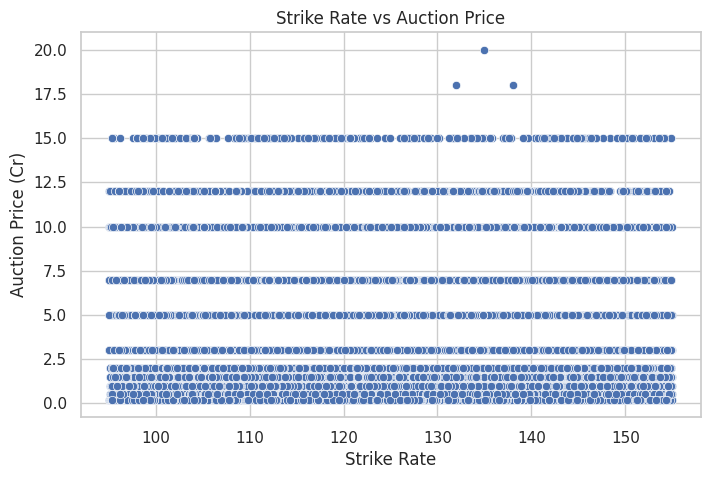

In [163]:
#Strike Rate vs Auction Price
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Strike_Rate",
    y="Auction_Price"
)

plt.title("Strike Rate vs Auction Price")
plt.xlabel("Strike Rate")
plt.ylabel("Auction Price (Cr)")
plt.show()

* The plot examines whether scoring efficiency, measured by strike rate, is associated with auction price. It helps determine whether strike rate provides useful information for explaining differences in player valuation.

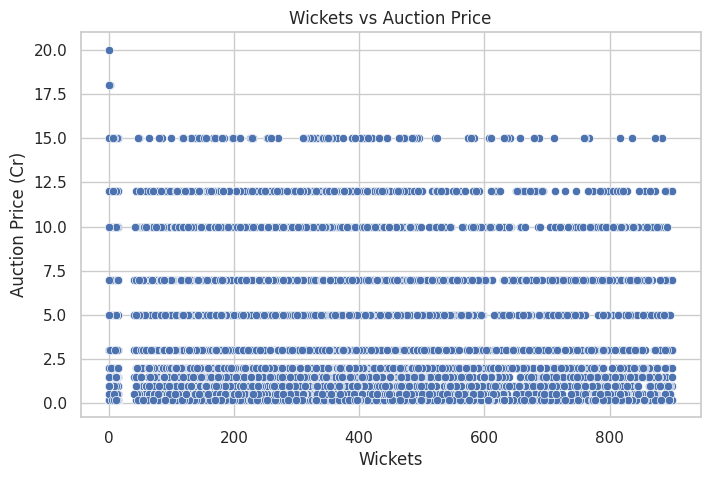

In [164]:
#Wickets vs Auction Price
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Wickets",
    y="Auction_Price"
)

plt.title("Wickets vs Auction Price")
plt.xlabel("Wickets")
plt.ylabel("Auction Price (Cr)")
plt.show()

* The relationship between wickets taken and auction price helps evaluate whether bowling performance influences player valuation. A visible positive trend would indicate that players with more wickets tend to have higher auction prices.

**Categorical Feature vs Target**

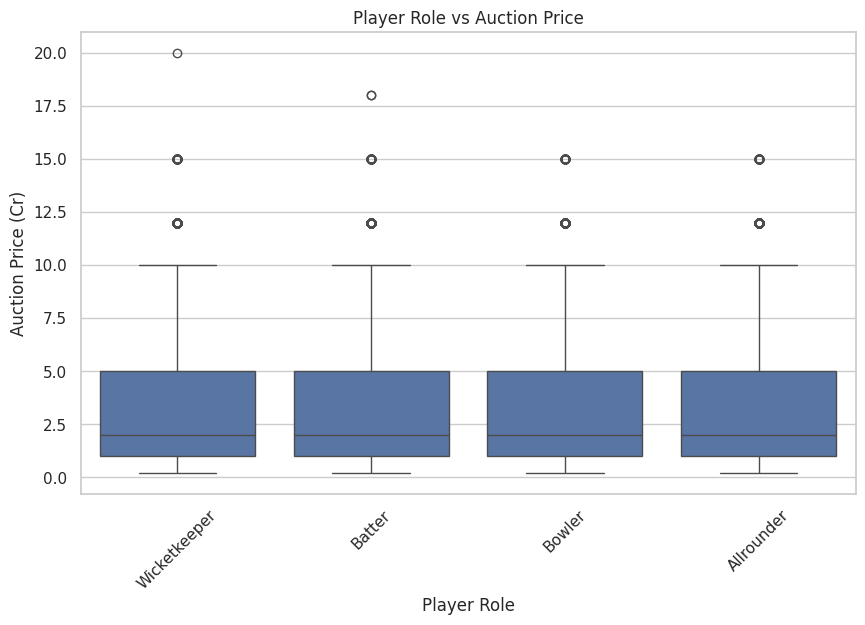

In [165]:
#Role vs Auction Price
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Role",
    y="Auction_Price"
)

plt.title("Player Role vs Auction Price")
plt.xlabel("Player Role")
plt.ylabel("Auction Price (Cr)")
plt.xticks(rotation=45)
plt.show()

* The boxplot compares auction-price distributions across different player roles. Differences in median prices and spread across roles can indicate that player role may contribute to differences in auction valuation.

**Correlation Analysis**

Now we'll check relationships between numerical variables.

In [166]:
# Correlation matrix
correlation_matrix = df[numerical_cols].corr()

display(correlation_matrix)

,Age,Matches,Experience_Years,Runs,Strike_Rate,Wickets,Economy,Average,Auction_Price
Age,1.000000,0.624875,0.653238,0.006050,0.020556,-0.007736,-0.012876,0.007840,0.007616
Matches,0.624875,1.000000,0.955948,0.003003,0.009072,-0.001992,-0.008704,0.002635,0.004371
Experience_Years,0.653238,0.955948,1.000000,0.004413,0.006993,-0.005289,-0.007121,-0.003005,0.004502
Runs,0.006050,0.003003,0.004413,1.000000,-0.012144,-0.580013,-0.065361,-0.005524,0.007932
Strike_Rate,0.020556,0.009072,0.006993,-0.012144,1.000000,-0.005943,-0.005511,-0.003388,-0.003833
Wickets,-0.007736,-0.001992,-0.005289,-0.580013,-0.005943,1.000000,0.285774,0.004993,-0.000665
Economy,-0.012876,-0.008704,-0.007121,-0.065361,-0.005511,0.285774,1.000000,0.004405,0.004957
Average,0.007840,0.002635,-0.003005,-0.005524,-0.003388,0.004993,0.004405,1.000000,-0.007938
Auction_Price,0.007616,0.004371,0.004502,0.007932,-0.003833,-0.000665,0.004957,-0.007938,1.000000


The correlation matrix measures the strength and direction of linear relationships between numerical variables. It is useful for identifying features that may have stronger relationships with Auction_Price as well as relationships between independent features.

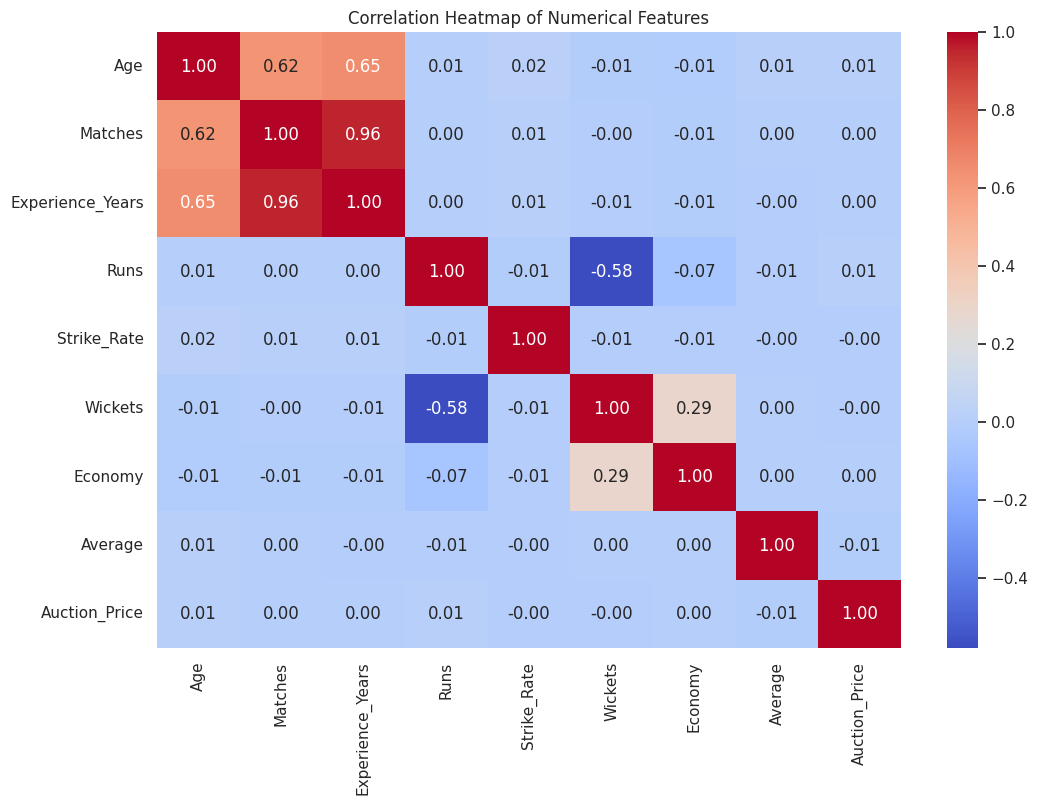

In [167]:
#Correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

The heatmap provides a visual summary of correlations among numerical variables. The Auction_Price row/column should be examined to identify features with relatively stronger positive or negative linear relationships with the target variable. Highly correlated independent features should also be monitored for potential multicollinearity.

**Multivariate Analysis**

Multivariate analysis means examining multiple variables together.

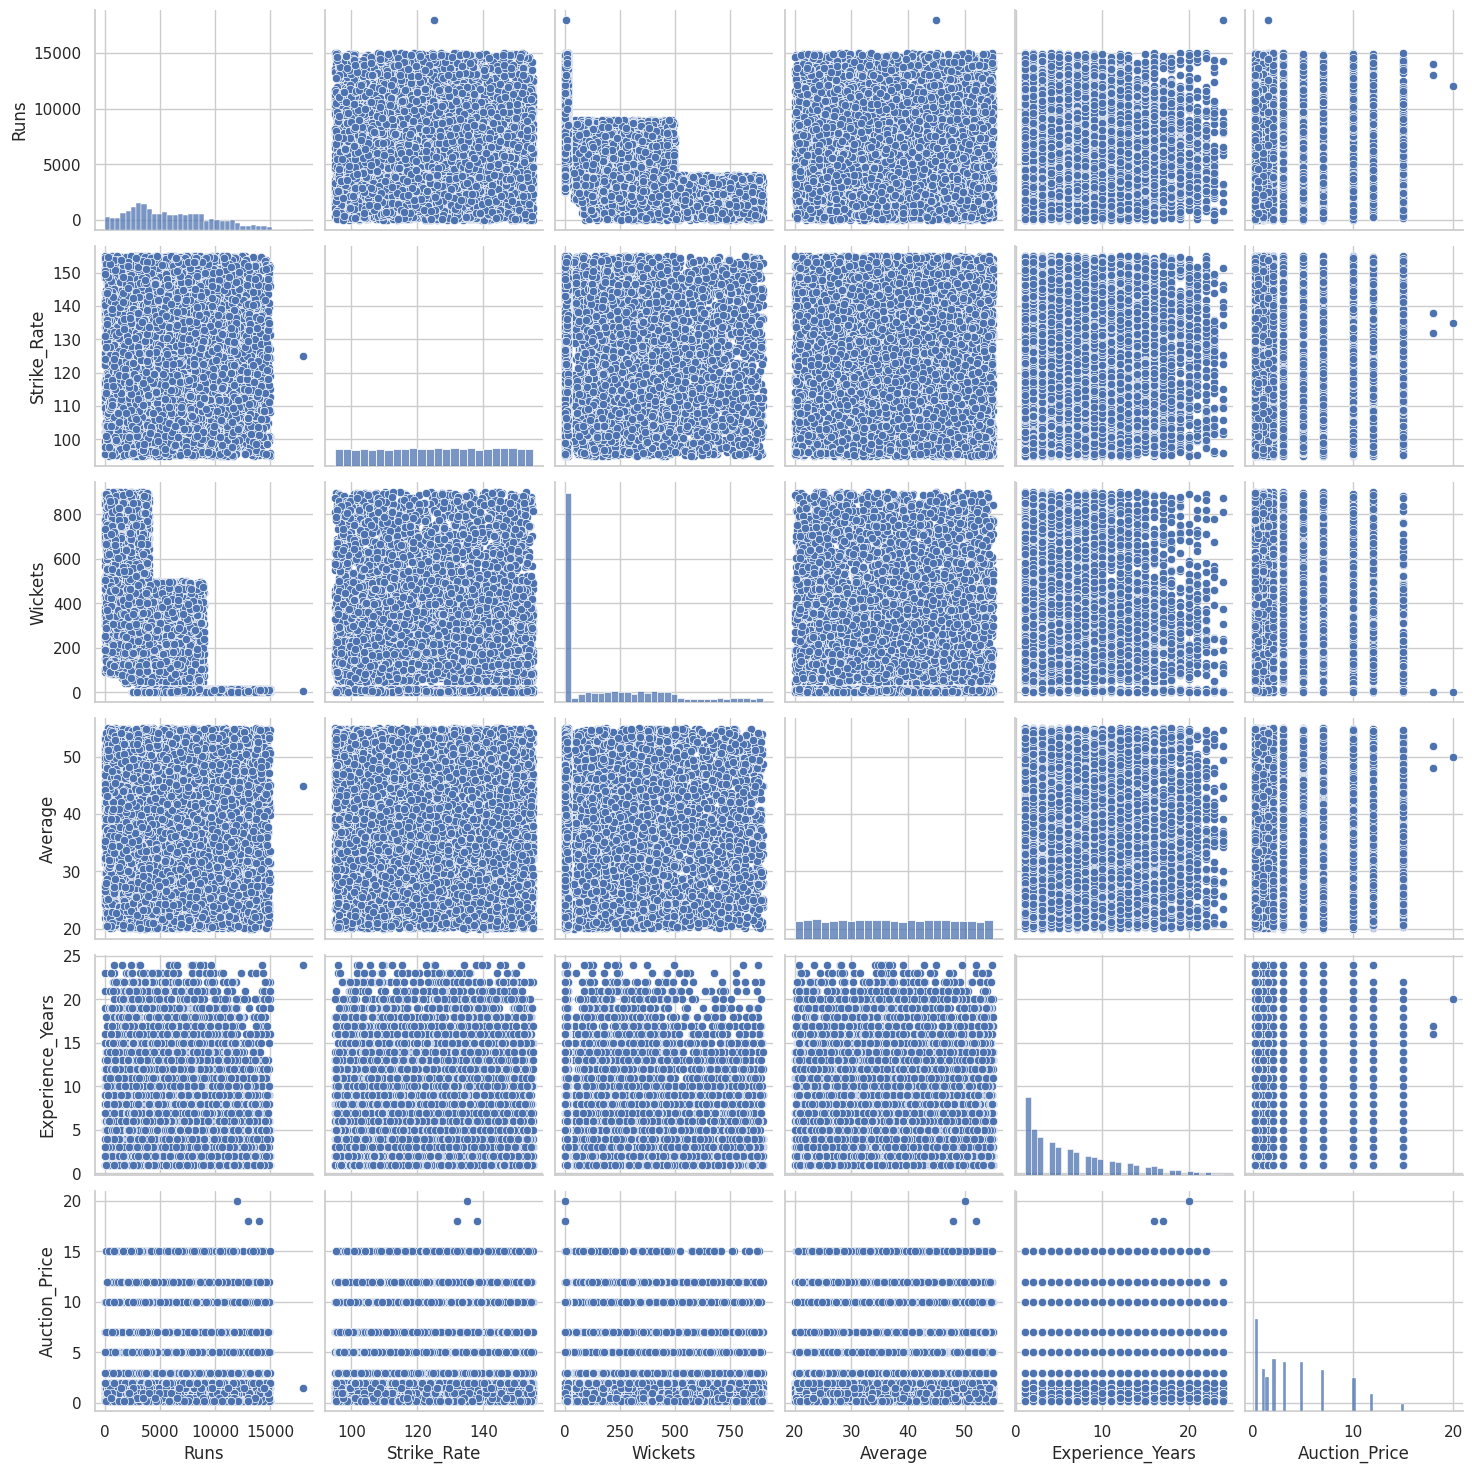

In [168]:
#Pairplot
pairplot_cols = [
    "Runs",
    "Strike_Rate",
    "Wickets",
    "Average",
    "Experience_Years",
    "Auction_Price"
]

sns.pairplot(
    df[pairplot_cols],
    diag_kind="hist"
)

plt.show()

Instead of putting every column into a pairplot—which can become difficult to read—we'll select the most important numerical features.

This helps us visually inspect:

* Runs ↔ Auction Price
* Strike Rate ↔ Auction Price
* Wickets ↔ Auction Price
* Average ↔ Auction Price
* Experience ↔ Auction Price
* Relationships between features themselves


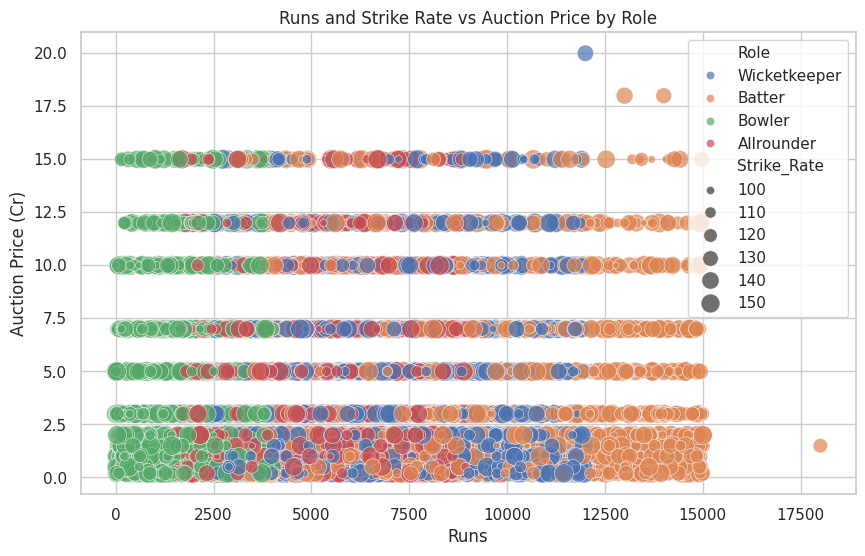

In [169]:
#Interaction Effects
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Runs",
    y="Auction_Price",
    hue="Role",
    size="Strike_Rate",
    sizes=(20, 200),
    alpha=0.7
)

plt.title("Runs and Strike Rate vs Auction Price by Role")
plt.xlabel("Runs")
plt.ylabel("Auction Price (Cr)")
plt.show()

Runs + Strike Rate + Auction Price

Here:

* X-axis → Runs
* Y-axis → Auction Price
* Color/group → Role
* Point size → Strike Rate

This gives us a more detailed view of the interaction between multiple variables.

**`Step 5: Outlier Detection & Treatment`**

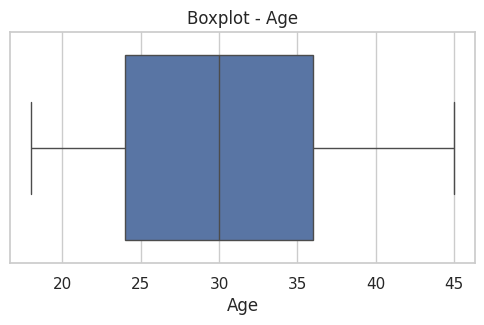

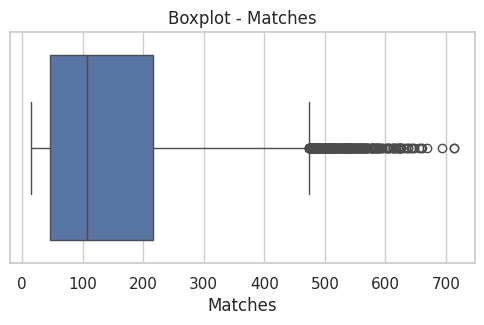

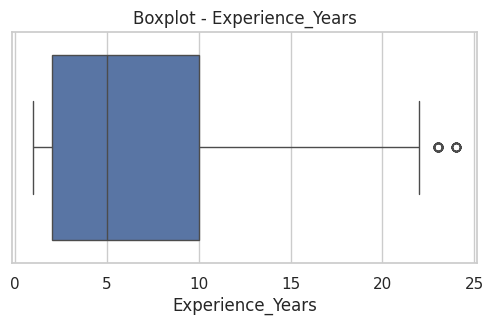

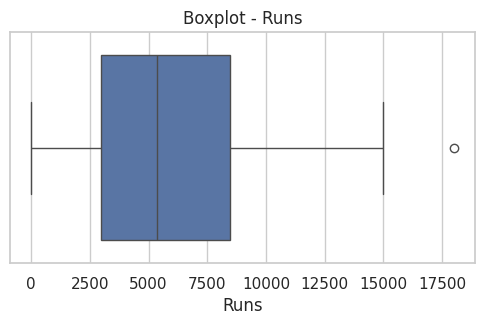

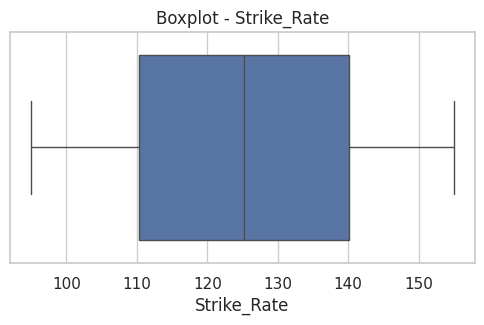

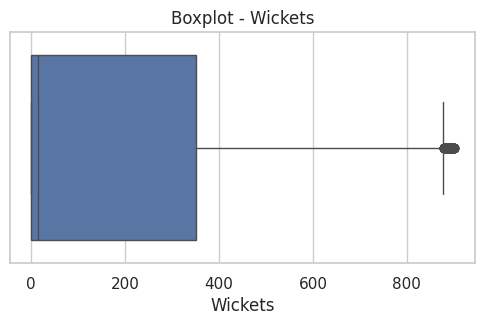

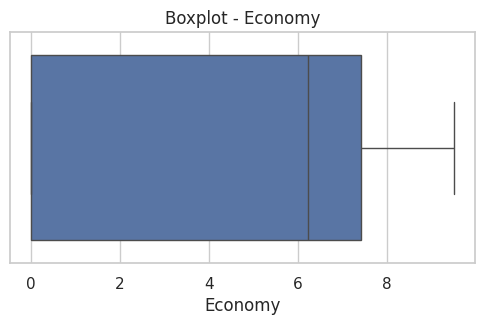

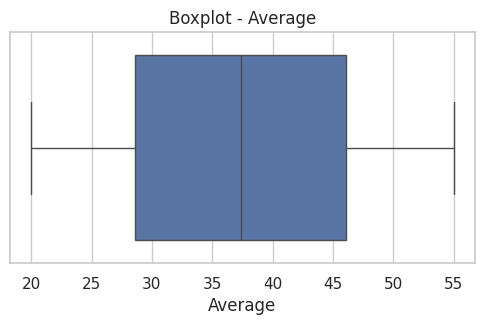

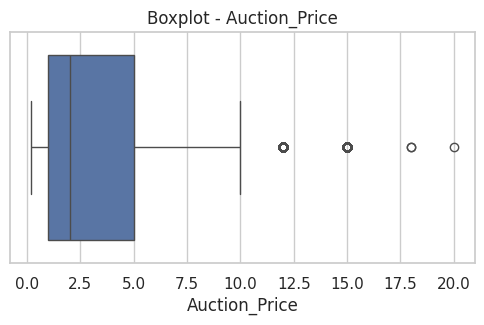

In [170]:
#Check outliers using Boxplots
for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

Boxplots help identify extreme values that may be potential outliers.

In [171]:
#Detect outliers using IQR
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers), "outliers")

Age : 0 outliers
Matches : 266 outliers
Experience_Years : 56 outliers
Runs : 1 outliers
Strike_Rate : 0 outliers
Wickets : 83 outliers
Economy : 0 outliers
Average : 0 outliers
Auction_Price : 710 outliers


The IQR method identifies observations that fall below the lower bound or above the upper bound.

In [172]:
#Treat outliers using Capping
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)
    print(df[col])

0        42
1        45
2        36
3        37
4        35
         ..
11995    29
11996    26
11997    29
11998    23
11999    38
Name: Age, Length: 12000, dtype: int64
0        350.0
1        400.0
2        300.0
3        280.0
4        196.0
         ...  
11995     22.0
11996     72.0
11997    153.0
11998     27.0
11999    102.0
Name: Matches, Length: 12000, dtype: float64
0        20
1        22
2        16
3        17
4         7
         ..
11995     1
11996     4
11997     9
11998     1
11999     6
Name: Experience_Years, Length: 12000, dtype: int64
0        12000.0
1        16645.5
2        13000.0
3        14000.0
4         2661.0
          ...   
11995    14111.0
11996     9945.0
11997    12993.0
11998     1771.0
11999     4980.0
Name: Runs, Length: 12000, dtype: float64
0        135.0
1        125.0
2        138.0
3        132.0
4        144.9
         ...  
11995    136.0
11996    104.1
11997    106.3
11998    133.2
11999    144.5
Name: Strike_Rate, Length: 12000, dtype: 

-> Instead of deleting genuine high-performing players, we'll cap extreme values.

-> Outliers are capped within the IQR boundaries to reduce their extreme influence while retaining the original records

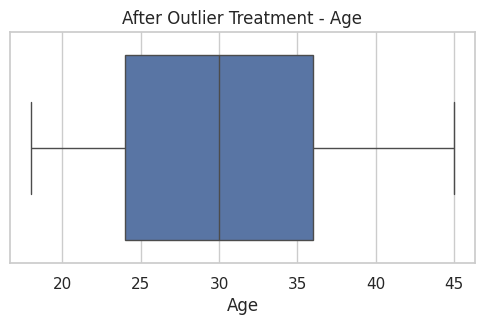

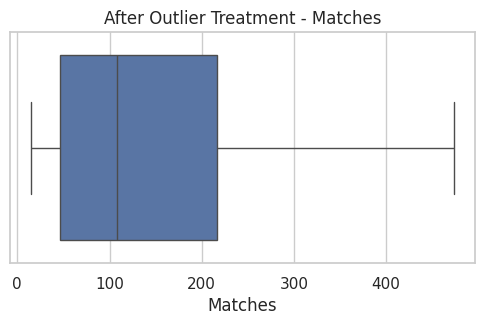

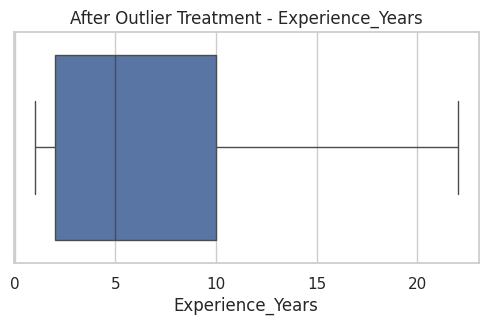

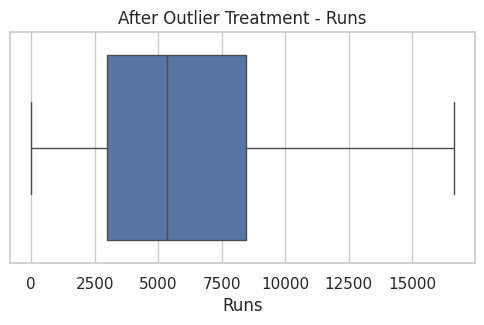

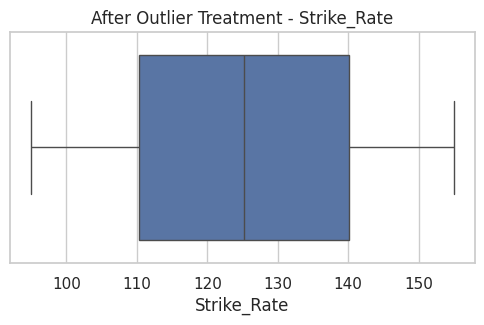

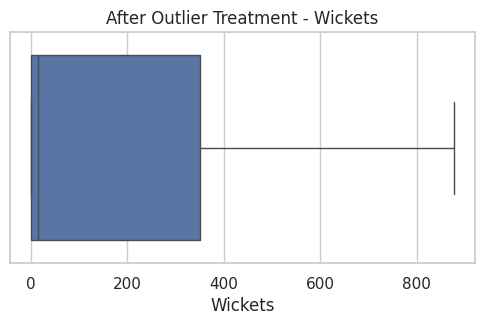

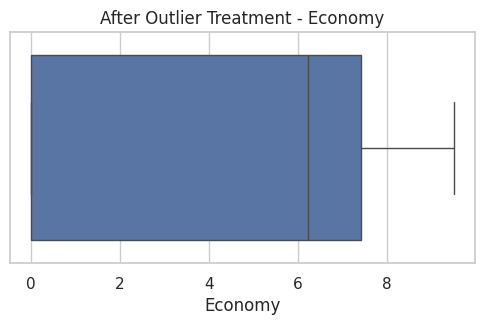

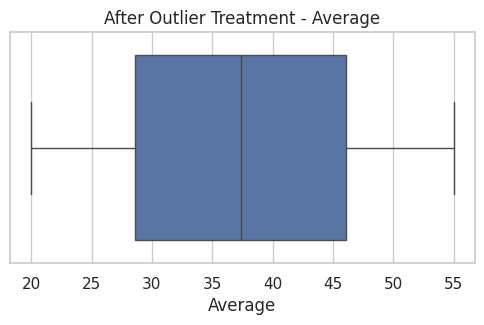

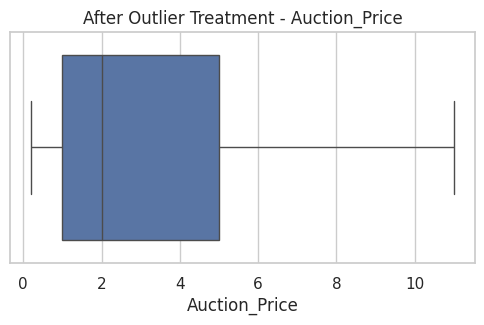

In [173]:
#Check again after treatment
for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"After Outlier Treatment - {col}")
    plt.show()

The boxplots after capping should show that extreme values have been limited.

**`Step 6: Feature Encoding`**

In [174]:
X = df.drop(columns=["Auction_Price"])
y = df["Auction_Price"]

In [175]:
X.head()

,Name,Age,Country,Role,Matches,Experience_Years,Runs,Strike_Rate,Wickets,Economy,Average,Team_Preference
0,MS Dhoni,42,India,Wicketkeeper,350.0,20,12000.0,135.0,0.0,0.00,50.00,CSK
1,Sachin Tendulkar,45,India,Batter,400.0,22,16645.5,125.0,5.0,8.50,45.00,MI
2,Virat Kohli,36,India,Batter,300.0,16,13000.0,138.0,2.0,7.00,52.00,RCB
3,Rohit Sharma,37,India,Batter,280.0,17,14000.0,132.0,0.0,8.00,48.00,MI
4,Jasprit Bumrah,35,India,Bowler,196.0,7,2661.0,144.9,798.0,7.69,27.43,MI


In [176]:
y.head()

,Auction_Price
0,11.0
1,1.5
2,11.0
3,11.0
4,11.0


In [177]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [178]:
numerical_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

In [179]:
numerical_cols

Index(['Age', 'Matches', 'Experience_Years', 'Runs', 'Strike_Rate', 'Wickets',
       'Economy', 'Average'],
      dtype='object')

In [180]:
categorical_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns

In [181]:
categorical_cols

Index(['Name', 'Country', 'Role', 'Team_Preference'], dtype='object')

In [182]:
nominal_cols = [
    'Country',
    'Role',
    'Team_Preference'
]

print(nominal_cols)

['Country', 'Role', 'Team_Preference']


In [183]:
#Numerical Pipeline
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [184]:
numerical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [185]:
#Nominl Pipeline
nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [186]:
nominal_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [187]:
#column transformer
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_cols),
    ("nominal", nominal_pipeline, nominal_cols),

])

In [188]:
preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['Age', 'Matches', 'Experience_Years', 'Runs', 'Strike_Rate', 'Wickets',
       'Economy', 'Average'],
      dtype='object')),
                                ('nominal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Country', 'Role', 'Team_Preference'])])

**Train Test Split**

In [189]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [190]:
print(X_train.shape)
print(X_test.shape)

(9600, 12)
(2400, 12)


In [191]:
X_train_transformed = preprocessor.fit_transform(X_train)

X_test_transformed = preprocessor.transform(X_test)

In [192]:
print(X_train_transformed.shape)
print(X_test_transformed.shape)

(9600, 31)
(2400, 31)


In [193]:
print(df.shape)
df.head()

(12000, 13)


,Name,Age,Country,Role,Matches,Experience_Years,Runs,Strike_Rate,Wickets,Economy,Average,Team_Preference,Auction_Price
0,MS Dhoni,42,India,Wicketkeeper,350.0,20,12000.0,135.0,0.0,0.00,50.00,CSK,11.0
1,Sachin Tendulkar,45,India,Batter,400.0,22,16645.5,125.0,5.0,8.50,45.00,MI,1.5
2,Virat Kohli,36,India,Batter,300.0,16,13000.0,138.0,2.0,7.00,52.00,RCB,11.0
3,Rohit Sharma,37,India,Batter,280.0,17,14000.0,132.0,0.0,8.00,48.00,MI,11.0
4,Jasprit Bumrah,35,India,Bowler,196.0,7,2661.0,144.9,798.0,7.69,27.43,MI,11.0


In [194]:
df.to_csv("cleaned_dataset.csv", index=False)

In [195]:
from google.colab import files

files.download("cleaned_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>